## Imports y carga de datos


In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit
import matplotlib.pyplot as plt

data = np.load("datos_6111.npz")
X, y, t = data["X"], data["y"], data["t"]   # X: (24,256), y: (24,), t: (256,)
print(X.shape, y.shape, t.shape)

K = 15
N = X.shape[1]   # 256


(24, 256) (24,) (256,)


In [2]:
# Configuracion global de estilo para todas las figuras del notebook
plt.rcParams.update({
    "text.usetex": False,           # mathtext interno: no requiere instalacion de LaTeX
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"], # cobertura Unicode completa (tildes, ñ); cmr10 no las tiene
    "mathtext.fontset": "cm",       # estilo Computer Modern solo para formulas ($...$)
    "axes.formatter.use_mathtext": True,
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

In [3]:

print("Clase de X:", type(X))
print("Tamaño:", X.shape[0])
print("N :", N)

print("X.shape =", X.shape)

print("X[0].shape =", X[0].shape)
print("X[1].shape =", X[1].shape)

print(len(X[0]), len(X[1]))

Clase de X: <class 'numpy.ndarray'>
Tamaño: 24
N : 256
X.shape = (24, 256)
X[0].shape = (256,)
X[1].shape = (256,)
256 256


## Parte 1 — Capa Fourier 
Construcción de W1​ (Fourier)

In [4]:
def construir_W1_fourier(t, K):
    """
    Filas 0..K-1   -> sin(2*pi*k*t)
    Filas K..2K-1  -> cos(2*pi*k*t)
    Retorna matriz (2K, N)
    """
    ks = jnp.arange(1, K + 1)[:, None]      # (K,1)
    tt = t[None, :]                          # (1,N)
    senos  = jnp.sin(2 * jnp.pi * ks * tt)   # (K,N)
    cosenos = jnp.cos(2 * jnp.pi * ks * tt)  # (K,N)
    return jnp.concatenate([senos, cosenos], axis=0)  # (2K,N)

W1_fourier = construir_W1_fourier(jnp.array(t), K)
print(W1_fourier.shape)  # (30, 256)

(30, 256)


Verificación contra np.fft
La idea: al proyectar una señal con W1FourierW_1^{Fourier}
W1Fourier​ obtienes (salvo escala) las partes real e imaginaria de su transformada de Fourier en esas mismas frecuencias k.

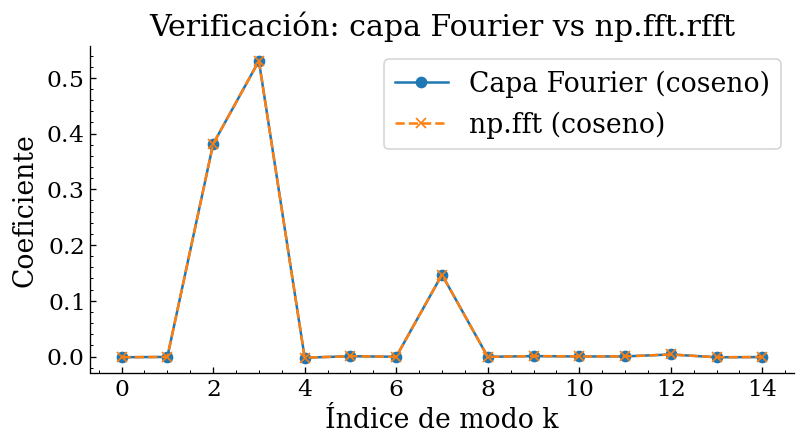

In [5]:
señal_prueba = X[0]
proy = W1_fourier @ señal_prueba   # (30,)

fft_ref = np.fft.rfft(señal_prueba)  # complejo, longitud N/2+1
#print(fft_ref)
# Comparamos componente k=1..K (ignorando k=0, la DC)
coef_coseno_manual = proy[K:] * (2 / N)   # filas de coseno
coef_seno_manual   = proy[:K] * (2 / N)   # filas de seno

coef_coseno_fft = fft_ref.real[1:K+1] * (2 / N)
coef_seno_fft   = -fft_ref.imag[1:K+1] * (2 / N)   # signo por convención

plt.figure(figsize=(7,4))
plt.plot(coef_coseno_manual, 'o-', label="Capa Fourier (coseno)")
plt.plot(coef_coseno_fft, 'x--', label="np.fft (coseno)")
plt.xlabel("Índice de modo k")
plt.ylabel("Coeficiente")
plt.title("Verificación: capa Fourier vs np.fft.rfft")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 0.** Las curvas de la capa Fourier y np.fft.rfft se superponen casi 
perfectamente, confirmando que W1 inicializada con senos y cosenos 
reproduce correctamente la transformada de Fourier de la señal.
La señal analizada presenta dos frecuencias dominantes: k=3 (coeficiente 
~0.53) y k=7 (~0.15). El resto de los modos tienen coeficiente cercano 
a cero, lo que indica que la señal está compuesta por muy pocas frecuencias 
bien definidas.

Energía media del dataset

In [6]:
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.673


## Parte 2 — Red, entrenamiento y reconstrucción

**Arquitectura y pérdida**

In [7]:
def forward(params, x):
    W1, W2 = params
    h = jnp.tanh(W1 @ x)
    return W2 @ h

def loss_fn(params, X):
    preds = jax.vmap(lambda x: forward(params, x))(X)
    return jnp.mean((preds - X)**2)

loss_grad = jit(grad(loss_fn))
loss_jit  = jit(loss_fn)

**Las dos inicializaciones**

In [8]:
key = jax.random.PRNGKey(0)

# W2 se inicializa igual en ambos casos (aleatoria pequeña)
key, subkey = jax.random.split(key)
W2_init = jax.random.normal(subkey, (N, 2*K)) * 0.05

# Init Fourier
params_fourier = (W1_fourier, W2_init)

# Init aleatoria
key, subkey = jax.random.split(key)
W1_random = jax.random.normal(subkey, (2*K, N)) * 0.05
params_random = (W1_random, W2_init)

**Bucle de entrenamiento (gradiente descendente simple)**

In [9]:
def entrenar(params, X, eta=0.1, iteraciones=2000):
    historia_loss = []
    for i in range(iteraciones):
        l = loss_jit(params, X)
        historia_loss.append(l)
        grads = loss_grad(params, X)
        params = tuple(p - eta * g for p, g in zip(params, grads))
    return params, jnp.array(historia_loss)

X_jax = jnp.array(X)

params_fourier_final, loss_fourier = entrenar(params_fourier, X_jax)
params_random_final,  loss_random  = entrenar(params_random,  X_jax)

**Gráfica: señal original vs reconstrucción (una por régimen)**

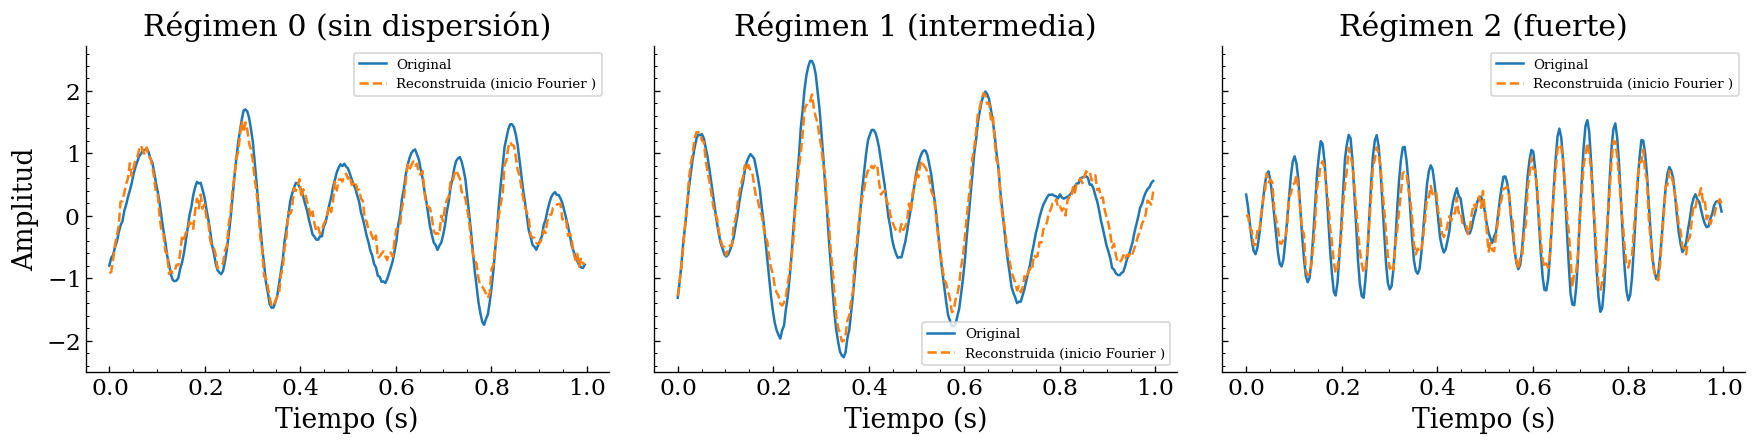

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)
nombres_regimen = ["Régimen 0 (sin dispersión)", "Régimen 1 (intermedia)", "Régimen 2 (fuerte)"]
numsign= 2
for r in range(3):
    idx = np.where(y == r)[0][numsign]   # primera señal de ese régimen o numsign_esima señal de ese regimen 
    x_orig = X[idx]
    x_hat = forward(params_fourier_final, jnp.array(x_orig))

    axes[r].plot(t, x_orig, label="Original", lw=1.5)
    axes[r].plot(t, x_hat, '--', label="Reconstruida (inicio Fourier )", lw=1.5)
    axes[r].set_title(nombres_regimen[r])
    axes[r].set_xlabel("Tiempo (s)")
    if r == 0:
        axes[r].set_ylabel("Amplitud")
    axes[r].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Figura 1.** Señal original (línea sólida) y reconstrucción $\hat x = W_2\tanh(W_1 x)$ de la red con inicialización Fourier tras 2000 iteraciones de entrenamiento (línea discontinua), para una señal representativa de cada régimen de dispersión ($\mu$ creciente de izquierda a derecha). El eje horizontal es el tiempo en segundos y el vertical la amplitud de la señal; los tres paneles comparten la misma escala vertical para facilitar la comparación entre regímenes. 

**Error de reconstrucción relativo de la numsign_esima señal**

In [17]:
def error_relativo(params, x):
    x_hat = forward(params, x)
    return jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x)

for r in range(3):
    idx = np.where(y == r)[0][numsign]
    x = jnp.array(X[idx])
    err_f = error_relativo(params_fourier_final, x)
    err_r = error_relativo(params_random_final, x)
    print(f"Régimen {r}: error Fourier={err_f:.4f}, error aleatoria={err_r:.4f}")

Régimen 0: error Fourier=0.2840, error aleatoria=0.2979
Régimen 1: error Fourier=0.2663, error aleatoria=0.2555
Régimen 2: error Fourier=0.3323, error aleatoria=0.3692


**Error de reconstrucción promedio**

In [18]:
print(f"{'Régimen':<10}{'Error prom. Fourier':<22}{'Error prom. Aleatoria':<22}")
for r in range(3):
    indices_regimen = np.where(y == r)[0]
    errores_f = [error_relativo(params_fourier_final, jnp.array(X[i])) for i in indices_regimen]
    errores_r = [error_relativo(params_random_final, jnp.array(X[i])) for i in indices_regimen]
    print(f"{r:<10}{np.mean(errores_f):<22.4f}{np.mean(errores_r):<22.4f}")

Régimen   Error prom. Fourier   Error prom. Aleatoria 
0         0.3494                0.3286                
1         0.3430                0.3146                
2         0.5311                0.3678                


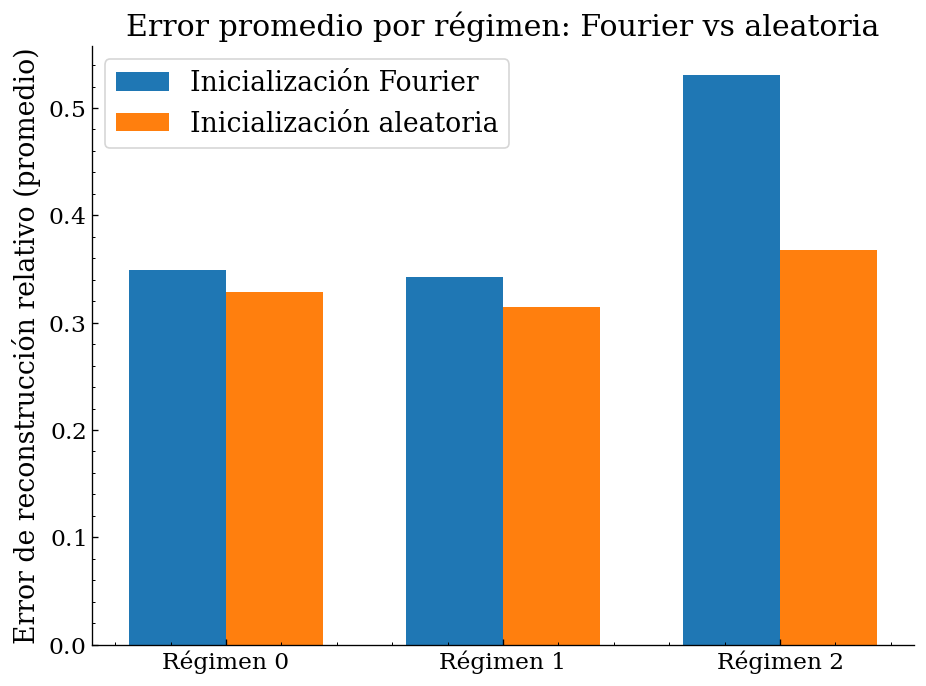

In [25]:
import matplotlib.pyplot as plt

regimenes = [0, 1, 2]
err_f_prom = []
err_r_prom = []

for r in regimenes:
    indices_regimen = np.where(y == r)[0]
    errores_f = [error_relativo(params_fourier_final, jnp.array(X[i])) for i in indices_regimen]
    errores_r = [error_relativo(params_random_final, jnp.array(X[i])) for i in indices_regimen]
    err_f_prom.append(np.mean(errores_f))
    err_r_prom.append(np.mean(errores_r))

x_pos = np.arange(len(regimenes))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(x_pos - width/2, err_f_prom, width, label="Inicialización Fourier")
ax.bar(x_pos + width/2, err_r_prom, width, label="Inicialización aleatoria")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Régimen 0", "Régimen 1", "Régimen 2"])
ax.set_ylabel("Error de reconstrucción relativo (promedio)")
ax.set_title("Error promedio por régimen: Fourier vs aleatoria")
ax.legend()
plt.tight_layout()
plt.show()

**Figura 2.** La inicialización aleatoria supera a Fourier en los tres regímenes. La ventaja crece con la complejidad de la señal: en régimen 0 la diferencia es marginal (~2 puntos porcentuales), pero en régimen 2 llega a ~16 puntos porcentuales. Esto sugiere que para señales de alta frecuencia, la rigidez estructural de la base de Fourier limita la capacidad del optimizador de encontrar una representación más eficiente, mientras que la inicialización aleatoria tiene mayor libertad para adaptarse a esas frecuencias durante el entrenamiento.

## Parte 3 — Comparación de inicializaciones
**Curvas de pérdida superpuestas**

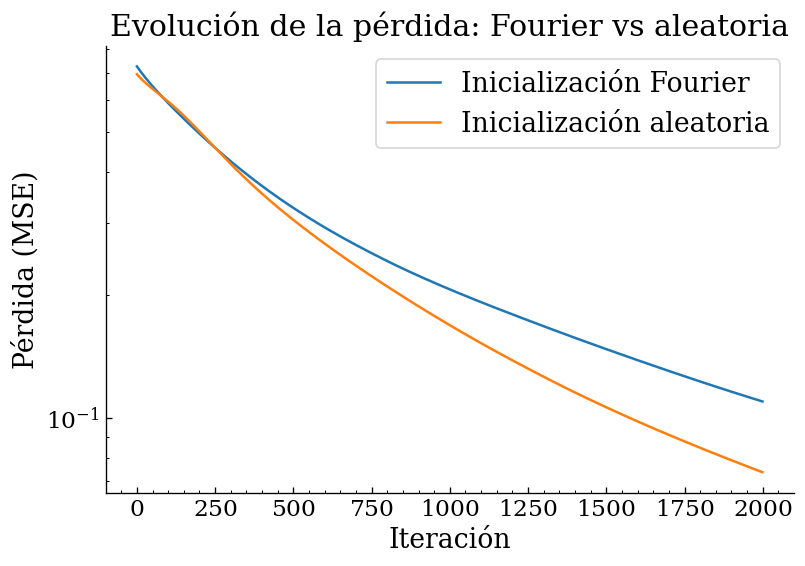

In [12]:
plt.figure(figsize=(7,5))
plt.plot(loss_fourier, label="Inicialización Fourier")
plt.plot(loss_random, label="Inicialización aleatoria")
plt.xlabel("Iteración")
plt.ylabel("Pérdida (MSE)")
plt.yscale("log")
plt.title("Evolución de la pérdida: Fourier vs aleatoria")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 3.** Evolución de la pérdida de entrenamiento (MSE, eje vertical en escala logarítmica) en función del número de iteraciones de descenso de gradiente, para la inicialización con la base de Fourier y para la inicialización aleatoria de $W_1$. Ambas curvas se calculan sobre las 24 señales del dataset (los tres regímenes combinados), con la misma tasa de aprendizaje $\eta=0.1$. 
La inicialización aleatoria converge más rápido y alcanza menor pérdida final que la inicialización Fourier. Aunque Fourier representa la base "correcta" para señales armónicas, su estructura rígida limita la libertad del optimizador. Ambas parten de pérdidas similares, pero la separación comienza alrededor de la iteración 300 y se mantiene hasta el final.

### Iteraciones para bajar de error relativo 0.1
Para esto conviene registrar el error relativo (no solo loss) en cada iteración:

In [13]:
def entrenar_con_error(params, X, eta=0.1, iteraciones=2000):
    historia_loss = []
    historia_err = []
    for i in range(iteraciones):
        l = loss_jit(params, X)
        preds = jax.vmap(lambda x: forward(params, x))(X)
        err = jnp.linalg.norm(preds - X) / jnp.linalg.norm(X)
        historia_loss.append(l)
        historia_err.append(err)
        grads = loss_grad(params, X)
        params = tuple(p - eta * g for p, g in zip(params, grads))
    return params, jnp.array(historia_loss), jnp.array(historia_err)

params_fourier_final, loss_f, err_f = entrenar_con_error(params_fourier, X_jax)
params_random_final, loss_r, err_r = entrenar_con_error(params_random, X_jax)

def iteracion_umbral(err_hist, umbral=0.1):
    idx = jnp.argmax(err_hist < umbral)
    return idx if err_hist[idx] < umbral else None  # None = nunca bajó del umbral

it_f = iteracion_umbral(err_f)
it_r = iteracion_umbral(err_r)
print(f"Fourier baja de 0.1 en la iteración: {it_f}")
print(f"Aleatoria baja de 0.1 en la iteración: {it_r}")

Fourier baja de 0.1 en la iteración: None
Aleatoria baja de 0.1 en la iteración: None


### Régimen difícil (régimen 0)

In [14]:
mask_r0 = (y == 0)
X_r0 = X_jax[mask_r0]

# Reentrena solo con régimen 0, o evalúa el error solo sobre ese subconjunto durante el entrenamiento ya hecho
err_f_r0 = jnp.linalg.norm(
    jax.vmap(lambda x: forward(params_fourier_final, x))(X_r0) - X_r0
) / jnp.linalg.norm(X_r0)

err_r_r0 = jnp.linalg.norm(
    jax.vmap(lambda x: forward(params_random_final, x))(X_r0) - X_r0
) / jnp.linalg.norm(X_r0)

print(f"Régimen 0 — error final Fourier: {err_f_r0:.4f}, aleatoria: {err_r_r0:.4f}")

Régimen 0 — error final Fourier: 0.3441, aleatoria: 0.3187


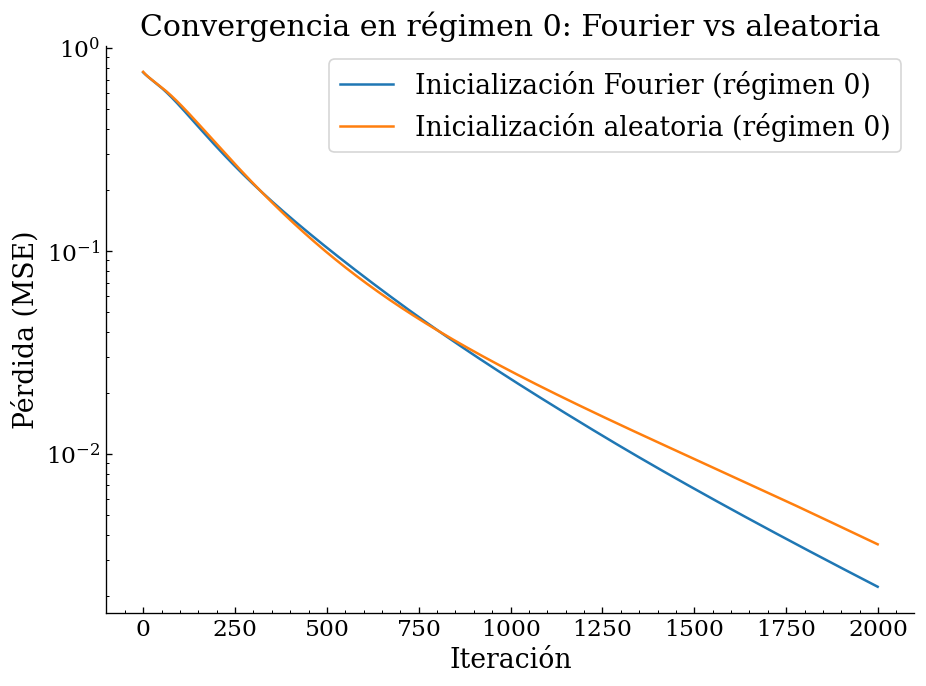

In [28]:
# Reentrenar solo con señales del régimen 0
params_f_r0, loss_f_r0, err_f_r0_hist = entrenar_con_error(params_fourier, X_r0)
params_r_r0, loss_r_r0, err_r_r0_hist = entrenar_con_error(params_random,  X_r0)

plt.figure(figsize=(8,6))
plt.plot(loss_f_r0, label="Inicialización Fourier (régimen 0)")
plt.plot(loss_r_r0, label="Inicialización aleatoria (régimen 0)")
plt.xlabel("Iteración")
plt.ylabel("Pérdida (MSE)")
plt.yscale("log")
plt.title("Convergencia en régimen 0: Fourier vs aleatoria")
plt.legend()
plt.tight_layout()
plt.show()

**Figura 3.1:**
Cuando se entrena aisladamente sobre el régimen 0 (sin dispersión), 
la inicialización Fourier supera a la aleatoria en velocidad de 
convergencia a partir de la iteración ~800, alcanzando una pérdida 
final aproximadamente 2 veces menor. Este resultado contrasta con 
el entrenamiento sobre los tres regímenes combinados, donde la 
aleatoria resultó mejor. La conclusión es que la inicialización 
Fourier es ventajosa cuando las señales del dataset son coherentes 
con la base de Fourier (pocas frecuencias bien definidas), pero 
pierde esa ventaja frente a señales más complejas o de mayor 
frecuencia (regímenes 1 y 2), donde la libertad de la inicialización 
aleatoria permite al optimizador encontrar mejores representaciones.

## Parte 4 — Compresión 

In [32]:
# Reconstrucción truncando coeficientes de Fourier (no de la red entrenada, sino de la transformada pura)
def reconstruir_con_m_coef(x, W1_fourier, m):
    coef = W1_fourier @ x
    coef_truncado = jnp.zeros_like(coef)
    # conserva los m coeficientes de mayor magnitud
    idx_top = jnp.argsort(jnp.abs(coef))[-m:]
    coef_truncado = coef_truncado.at[idx_top].set(coef[idx_top])
    # reconstrucción aproximada (pseudo-inversa de W1_fourier)
    W1_pinv = jnp.linalg.pinv(W1_fourier)
    return W1_pinv @ coef_truncado

errores_m = []
ms = range(1, 2*K + 1)
x_ejemplo = X_jax[0]

for m in ms:
    x_hat = reconstruir_con_m_coef(x_ejemplo, W1_fourier, m)
    err = jnp.linalg.norm(x_hat - x_ejemplo) / jnp.linalg.norm(x_ejemplo)
    errores_m.append(err)


# Coeficientes necesarios para 85% de energía
coef = W1_fourier @ x_ejemplo
energia_total = jnp.sum(coef**2)
coef_ordenado = jnp.sort(jnp.abs(coef))[::-1]
energia_acum = jnp.cumsum(coef_ordenado**2) / energia_total
m_85 = jnp.argmax(energia_acum >= 0.85) + 1
print(f"Coeficientes necesarios para 85% de la energía: {m_85}")

Coeficientes necesarios para 85% de la energía: 4


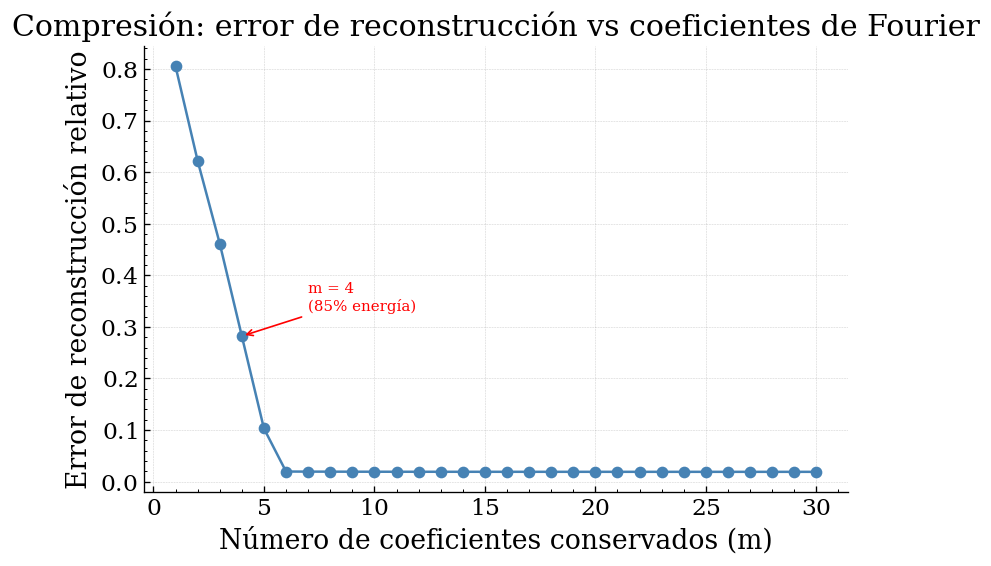

In [33]:
plt.figure(figsize=(7,5))
plt.plot(ms, errores_m, 'o-', color='steelblue', label="Error de reconstrucción")

# Anotación puntual en lugar de línea vertical
plt.annotate(
    f"m = {m_85}\n(85% energía)",
    xy=(m_85, errores_m[m_85 - 1]),
    xytext=(m_85 + 3, errores_m[m_85 - 1] + 0.05),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
    fontsize=9
)

plt.xlabel("Número de coeficientes conservados (m)")
plt.ylabel("Error de reconstrucción relativo")
plt.title("Compresión: error de reconstrucción vs coeficientes de Fourier")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Figura 4.**
La curva muestra cómo el error de reconstrucción cae a medida que se 
conservan más coeficientes de Fourier (de los 30 disponibles, 2K con K=15).

**Comportamiento general:** la caída es dramática entre m=1 y m=6, 
y luego la curva se aplana cerca de 0.02 sin mejorar significativamente 
al agregar más coeficientes. Esto confirma que la información de la señal 
está fuertemente concentrada en muy pocos modos frecuenciales, coherente 
con la física del problema: cada señal es suma de pocos cosenos a 
frecuencias bien definidas.

**Umbral del 85% de energía:** con solo m=4 coeficientes (de 30 posibles) 
ya se captura el 85% de la energía total de la señal, aunque el error de 
reconstrucción en ese punto es aún ~0.29. Para obtener un error bajo 
(~0.02) se necesitan aproximadamente 6-7 coeficientes. Es decir, con 
apenas el 20-23% de los coeficientes disponibles se logra una 
reconstrucción de alta calidad.

**Conclusión:** la señal es altamente compresible en la base de Fourier. 
Esto respalda la elección de K=15 frecuencias para la red: con mucho menos 
de eso ya se captura casi toda la información relevante.